In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Chargement des données
df = pd.read_csv('data.csv')
print("Dimensions du dataset :", df.shape)
print("\nPremières lignes :")
df.head(2)

In [63]:
df["Indicator Code"].unique()

array(['UIS.NERA.3', 'NY.GDP.PCAP.CD', 'SE.XPD.TOTL.GD.ZS', 'SE.TER.ENRR',
       'SE.SEC.ENRR.UP', 'IT.NET.USER.P2', 'SE.SEC.CMPT.LO.ZS',
       'SP.SEC.TOTL.IN', 'SP.TER.TOTL.IN', 'SP.SEC.UTOT.IN',
       'SE.ADT.1524.LT.ZS'], dtype=object)

In [ ]:
# Aperçu des colonnes
print("Colonnes disponibles :")
for col in df.columns:
    print(f"- {col}")


In [65]:
missing_data = df.isnull().sum()
missing_data

Country Name        0
Indicator Name      0
Indicator Code      0
2005              170
2006              177
2007              180
2008              165
2009              166
2010              151
2011              150
2012              151
2013              168
2014              168
2015              240
dtype: int64

In [66]:
# Vérification des valeurs manquantes
missing_data = df.isnull().sum()
missing_percentage = (missing_data / len(df)) * 100

print("Valeurs manquantes par colonne :")
for col in df.columns:
    if missing_data[col] > 0:
        print(f"{col}: {missing_data[col]} valeurs manquantes ({missing_percentage[col]:.2f}%)")

Valeurs manquantes par colonne :
2005: 170 valeurs manquantes (32.20%)
2006: 177 valeurs manquantes (33.52%)
2007: 180 valeurs manquantes (34.09%)
2008: 165 valeurs manquantes (31.25%)
2009: 166 valeurs manquantes (31.44%)
2010: 151 valeurs manquantes (28.60%)
2011: 150 valeurs manquantes (28.41%)
2012: 151 valeurs manquantes (28.60%)
2013: 168 valeurs manquantes (31.82%)
2014: 168 valeurs manquantes (31.82%)
2015: 240 valeurs manquantes (45.45%)


In [67]:
# Affichage des indicateurs Choisis
indicators = df['Indicator Name'].unique()
print(f"Nombre total d'indicateurs différents : {len(indicators)}")
print("\n dont :")
for i in indicators[:20]:
    print(f"- {i}")

Nombre total d'indicateurs différents : 11

 dont :
- Adjusted net enrolment rate, upper secondary, both sexes (%)
- GDP per capita (current US$)
- Government expenditure on education as % of GDP (%)
- Gross enrolment ratio, tertiary, both sexes (%)
- Gross enrolment ratio, upper secondary, both sexes (%)
- Internet users (per 100 people)
- Lower secondary completion rate, both sexes (%)
- Population of the official age for secondary education, both sexes (number)
- Population of the official age for tertiary education, both sexes (number)
- Population of the official age for upper secondary education, both sexes (number)
- Youth literacy rate, population 15-24 years, both sexes (%)


In [68]:
# Pivoter les données pour avoir une ligne par pays et des colonnes par indicateur/année
years = [str(year) for year in range(2005, 2016)]

In [69]:
# Créer un dataframe avec une ligne par pays et indicateur
pivot_df = df.melt(
    id_vars=['Country Name', 'Indicator Name', 'Indicator Code'],
    value_vars=years,
    var_name='Year',
    value_name='Value'
)
pivot_df

,Country Name,Indicator Name,Indicator Code,Year,Value
0,Angola,"Adjusted net enrolment rate, upper secondary, ...",UIS.NERA.3,2005,NaN
1,Angola,GDP per capita (current US$),NY.GDP.PCAP.CD,2005,1.443992e+03
2,Angola,Government expenditure on education as % of GD...,SE.XPD.TOTL.GD.ZS,2005,2.777130e+00
3,Angola,"Gross enrolment ratio, tertiary, both sexes (%)",SE.TER.ENRR,2005,2.748780e+00
4,Angola,"Gross enrolment ratio, upper secondary, both s...",SE.SEC.ENRR.UP,2005,NaN
...,...,...,...,...,...
5803,Zimbabwe,"Lower secondary completion rate, both sexes (%)",SE.SEC.CMPT.LO.ZS,2015,NaN
5804,Zimbabwe,Population of the official age for secondary e...,SP.SEC.TOTL.IN,2015,2.047619e+06
5805,Zimbabwe,Population of the official age for tertiary ed...,SP.TER.TOTL.IN,2015,1.607620e+06
5806,Zimbabwe,Population of the official age for upper secon...,SP.SEC.UTOT.IN,2015,1.342035e+06


In [70]:
# Convertir Year en numérique
pivot_df['Year'] = pivot_df['Year'].astype(int)
#pivot_df['Year'].dtype

In [71]:
# Pivoter pour avoir une colonne par indicateur
wide_df = pivot_df.pivot_table(
    index=['Country Name', 'Year'],
    columns='Indicator Name',
    values='Value'
).reset_index()

print("Nouvelle structure des données préparées pour le MAS :")
print(f"Dimensions : {wide_df.shape}")
print(f"Pays uniques : {wide_df['Country Name'].nunique()}")
print(f"Années : {wide_df['Year'].min()} à {wide_df['Year'].max()}")
wide_df

Nouvelle structure des données préparées pour le MAS :
Dimensions : (528, 13)
Pays uniques : 48
Années : 2005 à 2015


Indicator Name,Country Name,Year,"Adjusted net enrolment rate, upper secondary, both sexes (%)",GDP per capita (current US$),Government expenditure on education as % of GDP (%),"Gross enrolment ratio, tertiary, both sexes (%)","Gross enrolment ratio, upper secondary, both sexes (%)",Internet users (per 100 people),"Lower secondary completion rate, both sexes (%)","Population of the official age for secondary education, both sexes (number)","Population of the official age for tertiary education, both sexes (number)","Population of the official age for upper secondary education, both sexes (number)","Youth literacy rate, population 15-24 years, both sexes (%)"
0,Angola,2005,NaN,1443.991929,2.77713,2.74878,NaN,1.143367,NaN,3057573.0,1752923.0,1213760.0,NaN
1,Angola,2006,NaN,2062.415149,2.85845,2.69178,15.733700,1.500000,NaN,3163550.0,1808992.0,1253195.0,NaN
2,Angola,2007,NaN,2878.837144,NaN,NaN,15.610410,1.700000,NaN,2647861.0,1800309.0,1248737.0,NaN
3,Angola,2008,2.973120,3868.578883,NaN,NaN,18.397141,1.900000,19.187860,2743329.0,1860205.0,1292043.0,NaN
4,Angola,2009,3.117240,3347.844850,NaN,NaN,19.258320,2.300000,19.393749,2845787.0,1923759.0,1338684.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,Zimbabwe,2011,NaN,840.949880,NaN,5.82376,NaN,8.400000,NaN,2009047.0,1601799.0,1331526.0,90.93070
524,Zimbabwe,2012,NaN,968.163871,8.38322,5.86867,36.237690,12.000000,64.476013,2007007.0,1601931.0,1327364.0,NaN
525,Zimbabwe,2013,32.071152,1026.388289,8.48536,5.87175,36.963619,15.500000,65.527359,2012733.0,1602843.0,1327040.0,NaN
526,Zimbabwe,2014,NaN,1031.104616,8.42933,NaN,NaN,16.364740,NaN,2026425.0,1604698.0,1331677.0,90.42812


In [72]:
wide_df["Lower secondary completion rate, both sexes (%)"].isna().sum()

np.int64(228)

In [73]:
# Renommer les colonnes pour plus de simplicité
column_mapping = {
    'Population of the official age for secondary education, both sexes (number)': 'Population_Secondary',
    'Population of the official age for tertiary education, both sexes (number)': 'Population_Tertiary',
    'Population of the official age for upper secondary education, both sexes (number)': 'Population_Upper_Secondary',
    'Gross enrolment ratio, upper secondary, both sexes (%)': 'Enrolment_Upper_Secondary',
    'Gross enrolment ratio, tertiary, both sexes (%)': 'Enrolment_Tertiary',
    'Lower secondary completion rate, both sexes (%)': 'Completion_Secondary',
    'Adjusted net enrolment rate, upper secondary, both sexes (%)': 'Net_Enrolment_Secondary',
    'Youth literacy rate, population 15-24 years, both sexes (%)': 'Youth_Literacy',
    'Internet users (per 100 people)': 'Internet_Users',
    'GDP per capita (current US$)': 'GDP_per_capita',
    'Government expenditure on education as % of GDP (%)': 'Education_Expenditure'
}

wide_df = wide_df.rename(columns=column_mapping)
wide_df

Indicator Name,Country Name,Year,Net_Enrolment_Secondary,GDP_per_capita,Education_Expenditure,Enrolment_Tertiary,Enrolment_Upper_Secondary,Internet_Users,Completion_Secondary,Population_Secondary,Population_Tertiary,Population_Upper_Secondary,Youth_Literacy
0,Angola,2005,NaN,1443.991929,2.77713,2.74878,NaN,1.143367,NaN,3057573.0,1752923.0,1213760.0,NaN
1,Angola,2006,NaN,2062.415149,2.85845,2.69178,15.733700,1.500000,NaN,3163550.0,1808992.0,1253195.0,NaN
2,Angola,2007,NaN,2878.837144,NaN,NaN,15.610410,1.700000,NaN,2647861.0,1800309.0,1248737.0,NaN
3,Angola,2008,2.973120,3868.578883,NaN,NaN,18.397141,1.900000,19.187860,2743329.0,1860205.0,1292043.0,NaN
4,Angola,2009,3.117240,3347.844850,NaN,NaN,19.258320,2.300000,19.393749,2845787.0,1923759.0,1338684.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
523,Zimbabwe,2011,NaN,840.949880,NaN,5.82376,NaN,8.400000,NaN,2009047.0,1601799.0,1331526.0,90.93070
524,Zimbabwe,2012,NaN,968.163871,8.38322,5.86867,36.237690,12.000000,64.476013,2007007.0,1601931.0,1327364.0,NaN
525,Zimbabwe,2013,32.071152,1026.388289,8.48536,5.87175,36.963619,15.500000,65.527359,2012733.0,1602843.0,1327040.0,NaN
526,Zimbabwe,2014,NaN,1031.104616,8.42933,NaN,NaN,16.364740,NaN,2026425.0,1604698.0,1331677.0,90.42812


In [ ]:
# Statistiques descriptives de base
print("Statistiques descriptives pour 2011 (année avec le plus de données possibles) :")
df_2011 = wide_df[wide_df['Year'] == 2011]

for col in df_2011.columns[2:]:  # Exclure Country Name et Year
    if pd.api.types.is_numeric_dtype(df_2011[col]):
        valid_data = df_2011[col].dropna()
        if len(valid_data) > 0:
            print(f"\n{col}:")
            print(f"  Nombre de pays avec données : {len(valid_data)}")
            print(f"  Moyenne : {valid_data.mean():.2f}")
            print(f"  Médiane : {valid_data.median():.2f}")
            print(f"  Min : {valid_data.min():.2f}")
            print(f"  Max : {valid_data.max():.2f}")

# Point 2: Analyse par pays - Identification du potentiel de marché - Calcul Market Attractiveness Score (MAS)

In [138]:
def _get_indicator_value(row, indicator_name, scale_indicators):
    """Helper function pour extraire les valeurs d'indicateurs"""
    if indicator_name == 'Population_Scolaire':
        pop_sec = row.get('Population_Secondary', 0)
        pop_ter = row.get('Population_Tertiary', 0)
        return pop_sec + pop_ter
    elif indicator_name == 'Scolarisation_Moyenne':
        enrol_sec = row.get('Enrolment_Upper_Secondary', 0)
        enrol_ter = row.get('Enrolment_Tertiary', 0)
        return (enrol_sec + enrol_ter) / 2
    elif indicator_name == 'Apprenants_Connectés':
        pop_sec = row.get('Population_Secondary', 0)
        pop_ter = row.get('Population_Tertiary', 0)
        internet = row.get('Internet_Users', 0)
        return (pop_sec + pop_ter) * (internet / 100)
    return 0

In [139]:
def calculate_mas_score(wide_df, base_year=2011):
    """
    Calcule le Market Attractiveness Score selon la méthodologie MAS
    """
    
    # Données pour l'année de base
    df_base = wide_df[wide_df['Year'] == base_year].copy()
    
    # Initialiser le dataframe des résultats
    mas_results = []
    
    for _, country_row in df_base.iterrows():
        country = country_row['Country Name']
        
        # Données historiques pour ce pays (calcul du momentum)
        df_country = wide_df[wide_df['Country Name'] == country]
        
        # Initialisation des scores
        scores = {'Country': country}
        
        # 1. SCALE SCORE (35%) - Taille du marché
        # -------------------------------------------------
        scale_indicators = []
        
        # Population scolaire totale
        pop_secondary = country_row.get('Population_Secondary', 0)
        pop_tertiary = country_row.get('Population_Tertiary', 0)
        total_pop_school = pop_secondary + pop_tertiary
        
        # Taux de scolarisation moyen
        enrol_secondary = country_row.get('Enrolment_Upper_Secondary', 0)
        enrol_tertiary = country_row.get('Enrolment_Tertiary', 0)
        
        # TAM Apprenants connectés = Population scolaire × Taux d'accès Internet
        internet_rate = (country_row.get('Internet_Users', 0)) / 100
        connected_learners = total_pop_school * internet_rate
        
        scale_indicators.append(('Population_Scolaire', total_pop_school))
        scale_indicators.append(('Scolarisation_Moyenne', (enrol_secondary + enrol_tertiary) / 2))
        scale_indicators.append(('Apprenants_Connectés', connected_learners))
        
        # Normalisation (Dans une implémentation réelle, on utilise min-max sur tous les pays)
        scale_scores = []
        for name, value in scale_indicators:
            # Trouver min et max sur tous les pays
            all_values = df_base.apply(
                lambda x: _get_indicator_value(x, name, scale_indicators), 
                axis=1
            ).dropna()
            
            if len(all_values) > 0 and all_values.max() > all_values.min():
                norm_score = (value - all_values.min()) / (all_values.max() - all_values.min()) * 100
                scale_scores.append(norm_score)
        
        scores['Scale_Score'] = np.mean(scale_scores) if scale_scores else 0
        
        # 2. MOMENTUM SCORE (25%) - Dynamique de croissance
        # -------------------------------------------------
        momentum_indicators = []
        
        if len(df_country) > 1:
            # Croissance Internet (CAGR sur la période)
            internet_series = df_country['Internet_Users'].dropna()
            if len(internet_series) >= 2:
                start_val = internet_series.iloc[0]
                end_val = internet_series.iloc[-1]
                years = len(internet_series) - 1
                if start_val > 0 and years > 0:
                    cagr_internet = ((end_val / start_val) ** (1/years) - 1) * 100
                    momentum_indicators.append(('Croissance_Internet', min(cagr_internet, 50)))  # Plafonné à 50%
            
            # Croissance population scolaire secondaire
            pop_series = df_country['Population_Secondary'].dropna()
            if len(pop_series) >= 2:
                pop_growth = ((pop_series.iloc[-1] - pop_series.iloc[0]) / pop_series.iloc[0]) * 100
                momentum_indicators.append(('Croissance_Population_Second', pop_growth))

            # Croissance population scolaire tertiaire
            pop_ser_t = df_country['Population_Tertiary'].dropna()
            if len(pop_ser_t) >= 2:
                pop_growth_t = ((pop_ser_t.iloc[-1] - pop_ser_t.iloc[0]) / pop_ser_t.iloc[0]) * 100
                momentum_indicators.append(('Croissance_Population_Tert', pop_growth_t))

            # Croissance du Taux d'achèvement du secondaire
            complete_second = df_country['Completion_Secondary'].dropna()
            if len(complete_second) >= 2:
                start_value = complete_second.iloc[0]
                end_value = complete_second.iloc[-1]
                year = len(complete_second) - 1
                if start_value > 0 and year > 0:
                    croiss_second = ((end_value / start_value) ** (1/year) - 1)*100
                    momentum_indicators.append(('Croissance_Complete_Secondary', croiss_second))  
        
        # Normalisation
        momentum_scores = []
        for name, value in momentum_indicators:
            momentum_scores.append(min(value * 2, 100))  # Conversion en score 0-100
        
        scores['Momentum_Score'] = np.mean(momentum_scores) if momentum_scores else 0
        
        # 3. ABILITY TO PAY SCORE (25%) - Capacité de paiement
        # -------------------------------------------------
        ability_indicators = []
        
        # PIB par habitant
        gdp = country_row.get('GDP_per_capita', 0)
        if gdp > 0:
            # Normalisation: 5000$ = 100 points, 500$ = 10 points
            gdp_score = min(100, (gdp / 5000) * 100)
            ability_indicators.append(('PIB_par_habitant', gdp_score))
        
        # Dépenses éducation
        edu_exp = country_row.get('Education_Expenditure', 0)
        if edu_exp > 0:
            # Normalisation: 10% = 100 points, 2% = 20 points
            edu_score = min(100, (edu_exp / 10) * 100)
            ability_indicators.append(('Depenses_Education', edu_score))
        
        # Calcul du score moyen
        ability_scores = [v for _, v in ability_indicators]
        scores['Ability_Score'] = np.mean(ability_scores) if ability_scores else 0
        
        # 4. DIGITAL READINESS SCORE (15%) - Faisabilité opérationnelle
        # -------------------------------------------------
        readiness_indicators = []
        
        # Accès Internet
        internet = country_row.get('Internet_Users', 0)
        internet_score = min(100, internet * 2)  # 50% = 100 points
        readiness_indicators.append(('Accès_Internet', internet_score))
        
        # Calcul du score moyen
        readiness_scores = [v for _, v in readiness_indicators]
        scores['Readiness_Score'] = np.mean(readiness_scores) if readiness_scores else 0
        
        # 5. CALCUL DU SCORE MAS FINAL
        # -------------------------------------------------
        weights = {
            'Scale_Score': 0.35,
            'Momentum_Score': 0.25,
            'Ability_Score': 0.25,
            'Readiness_Score': 0.15
        }
        
        mas_final = 0
        for component, weight in weights.items():
            mas_final += scores.get(component, 0) * weight
        
        scores['MAS_Final'] = mas_final
        
        # 6. AJUSTEMENT QUALITÉ DONNÉES
        # -------------------------------------------------
        data_points = 0
        total_indicators = 0
        
        for indicator in ['Population_Secondary', 'Internet_Users', 
                         'GDP_per_capita', 'Education_Expenditure',
                         'Enrolment_Upper_Secondary']:
            total_indicators += 1
            if indicator in country_row and not pd.isna(country_row[indicator]):
                data_points += 1
        
        data_completeness = data_points / total_indicators if total_indicators > 0 else 0
        scores['Data_Completeness'] = data_completeness
        
        # Ajustement du score final (pénalité pour données incomplètes)
        adjusted_mas = mas_final * (0.5 + 0.5 * data_completeness)
        scores['MAS_Adjusted'] = adjusted_mas
        
        # Ajouter les données brutes pour référence
        scores['Population_Secondary'] = pop_secondary
        scores['Internet_Users'] = country_row.get('Internet_Users', 0)
        scores['GDP_per_capita'] = gdp
        scores['Education_Expenditure'] = edu_exp
        
        mas_results.append(scores)
    
    return pd.DataFrame(mas_results)
        

In [140]:
# Calcul du MAS pour tous les pays
mas_df = calculate_mas_score(wide_df, base_year=2011)
mas_df = mas_df.sort_values('MAS_Adjusted', ascending=False)

print("\n" + "=" * 100)
print("\t \t \tMARKET ATTRACTIVENESS SCORE (MAS) - RÉSULTATS 2011")
print("=" * 100)
print(f"\nTop 10 pays par score MAS (ajusté):\n")

for i, (_, row) in enumerate(mas_df.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['Country']:25s} "
          f"MAS: {row['MAS_Adjusted']:5.1f}/100 "
          f"| Taille: {row['Scale_Score']:4.0f} "
          f"| Dyn: {row['Momentum_Score']:4.0f} "
          f"| Solv: {row['Ability_Score']:4.0f} "
          f"| Num: {row['Readiness_Score']:4.0f}")

print(f"\nMoyennes globales:")
print(f"• MAS moyen: {mas_df['MAS_Adjusted'].mean():.1f}/100")
print(f"• Taille moyenne: {mas_df['Scale_Score'].mean():.1f}")
print(f"• Dynamique moyenne: {mas_df['Momentum_Score'].mean():.1f}")
print(f"• Solvabilité moyenne: {mas_df['Ability_Score'].mean():.1f}")
print(f"• Numérique moyenne: {mas_df['Readiness_Score'].mean():.1f}")


	 	 	MARKET ATTRACTIVENESS SCORE (MAS) - RÉSULTATS 2011

Top 10 pays par score MAS (ajusté):

 1. Nigeria                   MAS:  51.3/100 | Taille:   81 | Dyn:   48 | Solv:   51 | Num:   28
 2. Mauritius                 MAS:  40.7/100 | Taille:   34 | Dyn:    6 | Solv:   67 | Num:   70
 3. Cabo Verde                MAS:  36.0/100 | Taille:   24 | Dyn:   10 | Solv:   62 | Num:   64
 4. Ghana                     MAS:  34.9/100 | Taille:   22 | Dyn:   41 | Solv:   56 | Num:   18
 5. Swaziland                 MAS:  33.8/100 | Taille:   14 | Dyn:   20 | Solv:   73 | Num:   36
 6. Angola                    MAS:  33.8/100 | Taille:   12 | Dyn:   44 | Solv:   86 | Num:    6
 7. Ethiopia                  MAS:  33.8/100 | Taille:   26 | Dyn:   66 | Solv:   31 | Num:    2
 8. Seychelles                MAS:  32.7/100 | Taille:   13 | Dyn:   -7 | Solv:   68 | Num:   86
 9. Sudan                     MAS:  32.2/100 | Taille:   27 | Dyn:   51 | Solv:   33 | Num:   35
10. Cameroon                  MA

##  SEGMENTATION DES PAYS PAR NIVEAU DE PRIORITÉ

In [141]:
# Définition des seuils de priorité
threshold_high = mas_df['MAS_Adjusted'].quantile(0.75)  # Top 25%
threshold_medium = mas_df['MAS_Adjusted'].quantile(0.50)  # Médiane

priority_1 = mas_df[mas_df['MAS_Adjusted'] >= threshold_high].copy()
priority_2 = mas_df[(mas_df['MAS_Adjusted'] >= threshold_medium) & 
                    (mas_df['MAS_Adjusted'] < threshold_high)].copy()
priority_3 = mas_df[mas_df['MAS_Adjusted'] < threshold_medium].copy()

print("\n" + "=" * 85)
print("\t\t\tSEGMENTATION STRATÉGIQUE BASÉE SUR LE MAS")
print("=" * 85)

print(f"\n🎯 PRIORITÉ 1 - Go-to-Market (MAS ≥ {threshold_high:.1f}) - {len(priority_1)} pays")
print("-" * 85)
for _, row in priority_1.sort_values('MAS_Adjusted', ascending=False).iterrows():
    print(f"• {row['Country']:25s} MAS: {row['MAS_Adjusted']:.2f} | "
          f"Internet: {row['Internet_Users']:.2f}% | "
          f"Population scolaire: {row['Population_Secondary']/1e6:.2f}M")

print(f"\n📈 PRIORITÉ 2 - Build & Partnerships ({threshold_medium:.1f} ≤ MAS < {threshold_high:.1f}) - {len(priority_2)} pays")
print("-" * 66)
for _, row in priority_2.sort_values('MAS_Adjusted', ascending=False).iterrows():
    print(f"• {row['Country']:25s} MAS: {row['MAS_Adjusted']:.2f} |"
         f"Internet: {row['Internet_Users']:.2f}% | "
          f"Population scolaire: {row['Population_Secondary']/1e6:.2f}M")

print(f"\n⏳ PRIORITÉ 3 - Niche / Long terme (MAS < {threshold_medium:.1f}) - {len(priority_3)} pays")
print("-" * 57)
for _, row in priority_3.sort_values('MAS_Adjusted', ascending=False).head(15).iterrows():
    print(f"• {row['Country']:25s} MAS: {row['MAS_Adjusted']:.2f} |"
         f"Internet: {row['Internet_Users']:.2f}% | "
          f"Population scolaire: {row['Population_Secondary']/1e6:.2f}M")

# Ajouter la catégorie de priorité au dataframe MAS
def assign_priority(mas_score):
    if mas_score >= threshold_high:
        return 'Priorité 1 - Go-to-Market'
    elif mas_score >= threshold_medium:
        return 'Priorité 2 - Build & Partnerships'
    else:
        return 'Priorité 3 - Niche / Long terme'

mas_df['Priority'] = mas_df['MAS_Adjusted'].apply(assign_priority)


			SEGMENTATION STRATÉGIQUE BASÉE SUR LE MAS

🎯 PRIORITÉ 1 - Go-to-Market (MAS ≥ 33.8) - 7 pays
-------------------------------------------------------------------------------------
• Nigeria                   MAS: 51.25 | Internet: 13.80% | Population scolaire: 21.24M
• Mauritius                 MAS: 40.68 | Internet: 34.95% | Population scolaire: 0.14M
• Cabo Verde                MAS: 35.98 | Internet: 32.00% | Population scolaire: 0.07M
• Ghana                     MAS: 34.92 | Internet: 9.00% | Population scolaire: 3.76M
• Swaziland                 MAS: 33.81 | Internet: 18.13% | Population scolaire: 0.15M
• Angola                    MAS: 33.81 | Internet: 3.10% | Population scolaire: 3.06M
• Ethiopia                  MAS: 33.77 | Internet: 1.10% | Population scolaire: 12.60M

📈 PRIORITÉ 2 - Build & Partnerships (24.1 ≤ MAS < 33.8) - 6 pays
------------------------------------------------------------------
• Seychelles                MAS: 32.74 |Internet: 43.16% | Population scolai

## 5. VISUALISATIONS BASÉES SUR LE MAS

### Ce graphique classe les 15 pays ayant les scores de Market Attractiveness Score (MAS) les plus élevés. Les pays en tête combinent une forte population cible, de bons niveaux de scolarisation secondaire et tertiaire, ainsi qu’un accès relativement élevé à l’Internet. Ils représentent les marchés les plus prometteurs pour une expansion rapide des services EdTech d’Akowé. Les pays en bas de classement nécessitent une approche exploratoire ou partenariale.

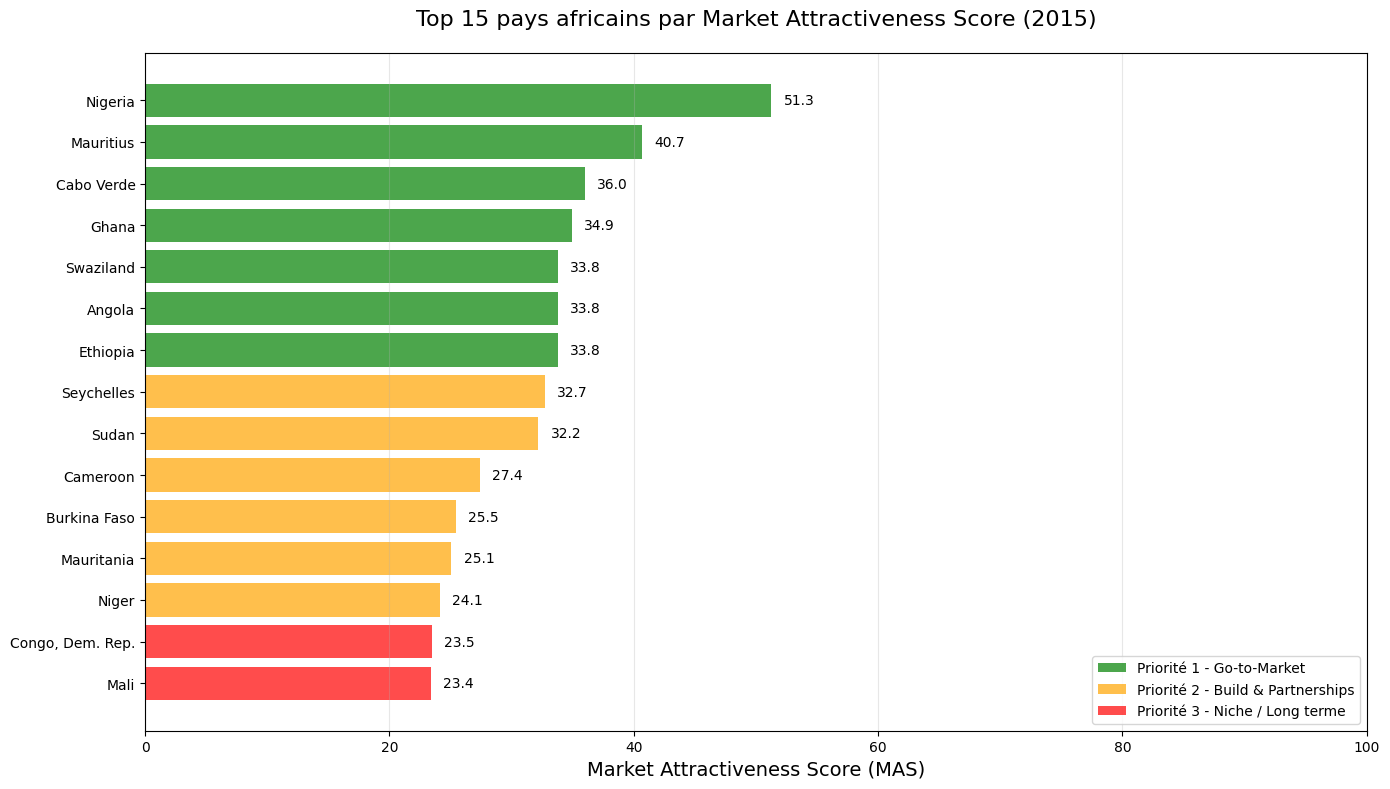

In [142]:
# Visualisation 1: Top 15 pays par MAS
plt.figure(figsize=(14, 8))
top_15 = mas_df.head(15).sort_values('MAS_Adjusted')
colors = ['green' if x >= threshold_high else 
          'orange' if x >= threshold_medium else 
          'red' for x in top_15['MAS_Adjusted']]

bars = plt.barh(top_15['Country'], top_15['MAS_Adjusted'], color=colors, alpha=0.7)
plt.xlabel('Market Attractiveness Score (MAS)', fontsize=14)
plt.title('Top 15 pays africains par Market Attractiveness Score (2015)', fontsize=16, pad=20)
plt.xlim([0, 100])

# Ajouter les valeurs sur les barres
for bar in bars:
    width = bar.get_width()
    plt.text(width + 1, bar.get_y() + bar.get_height()/2, 
             f'{width:.1f}', va='center', fontsize=10)

# Légende pour les couleurs
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='green', alpha=0.7, label='Priorité 1 - Go-to-Market'),
    Patch(facecolor='orange', alpha=0.7, label='Priorité 2 - Build & Partnerships'),
    Patch(facecolor='red', alpha=0.7, label='Priorité 3 - Niche / Long terme')
]
plt.legend(handles=legend_elements, loc='lower right')

plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('mas_top_countries.png', dpi=300, bbox_inches='tight')
plt.show()

### 1. Distribution des scores MAS (histogramme) :L’histogramme montre une distribution asymétrique des scores MAS, avec une majorité de pays concentrés sur des valeurs faibles à moyennes. Cela indique que peu de pays cumulent simultanément de bonnes conditions éducatives et technologiques, ce qui justifie une stratégie de ciblage sélectif plutôt qu’une expansion uniforme sur tout le continent.

### 2. Détail des composantes du MAS (Top 5 pays) : Les pays à grande taille de marché offrent un fort volume potentiel mais impliquent une complexité opérationnelle accrue.Les pays plus petits mais numériquement matures sont adaptés à un lancement rapide de solutions EdTech.Le MAS agrège efficacement des profils complémentaires : volume, croissance, capacité de paiement et readiness digitale.

### 3. Distribution du MAS selon le niveau de connectivité : L’accès à Internet est un facteur clé de l’attractivité des marchés EdTech.Les pays très connectés constituent des cibles prioritaires pour des offres digitales standardisées.Les pays faiblement connectés relèvent davantage d’une stratégie long terme, nécessitant adaptation technologique et partenariats institutionnels.

### 4. Répartition des pays par niveau de priorité : Le marché africain offre un potentiel important mais hétérogène.Seule une minorité de pays est immédiatement exploitable.La majorité nécessite une construction progressive du marché, confirmant la nécessité d’une allocation sélective des ressources.

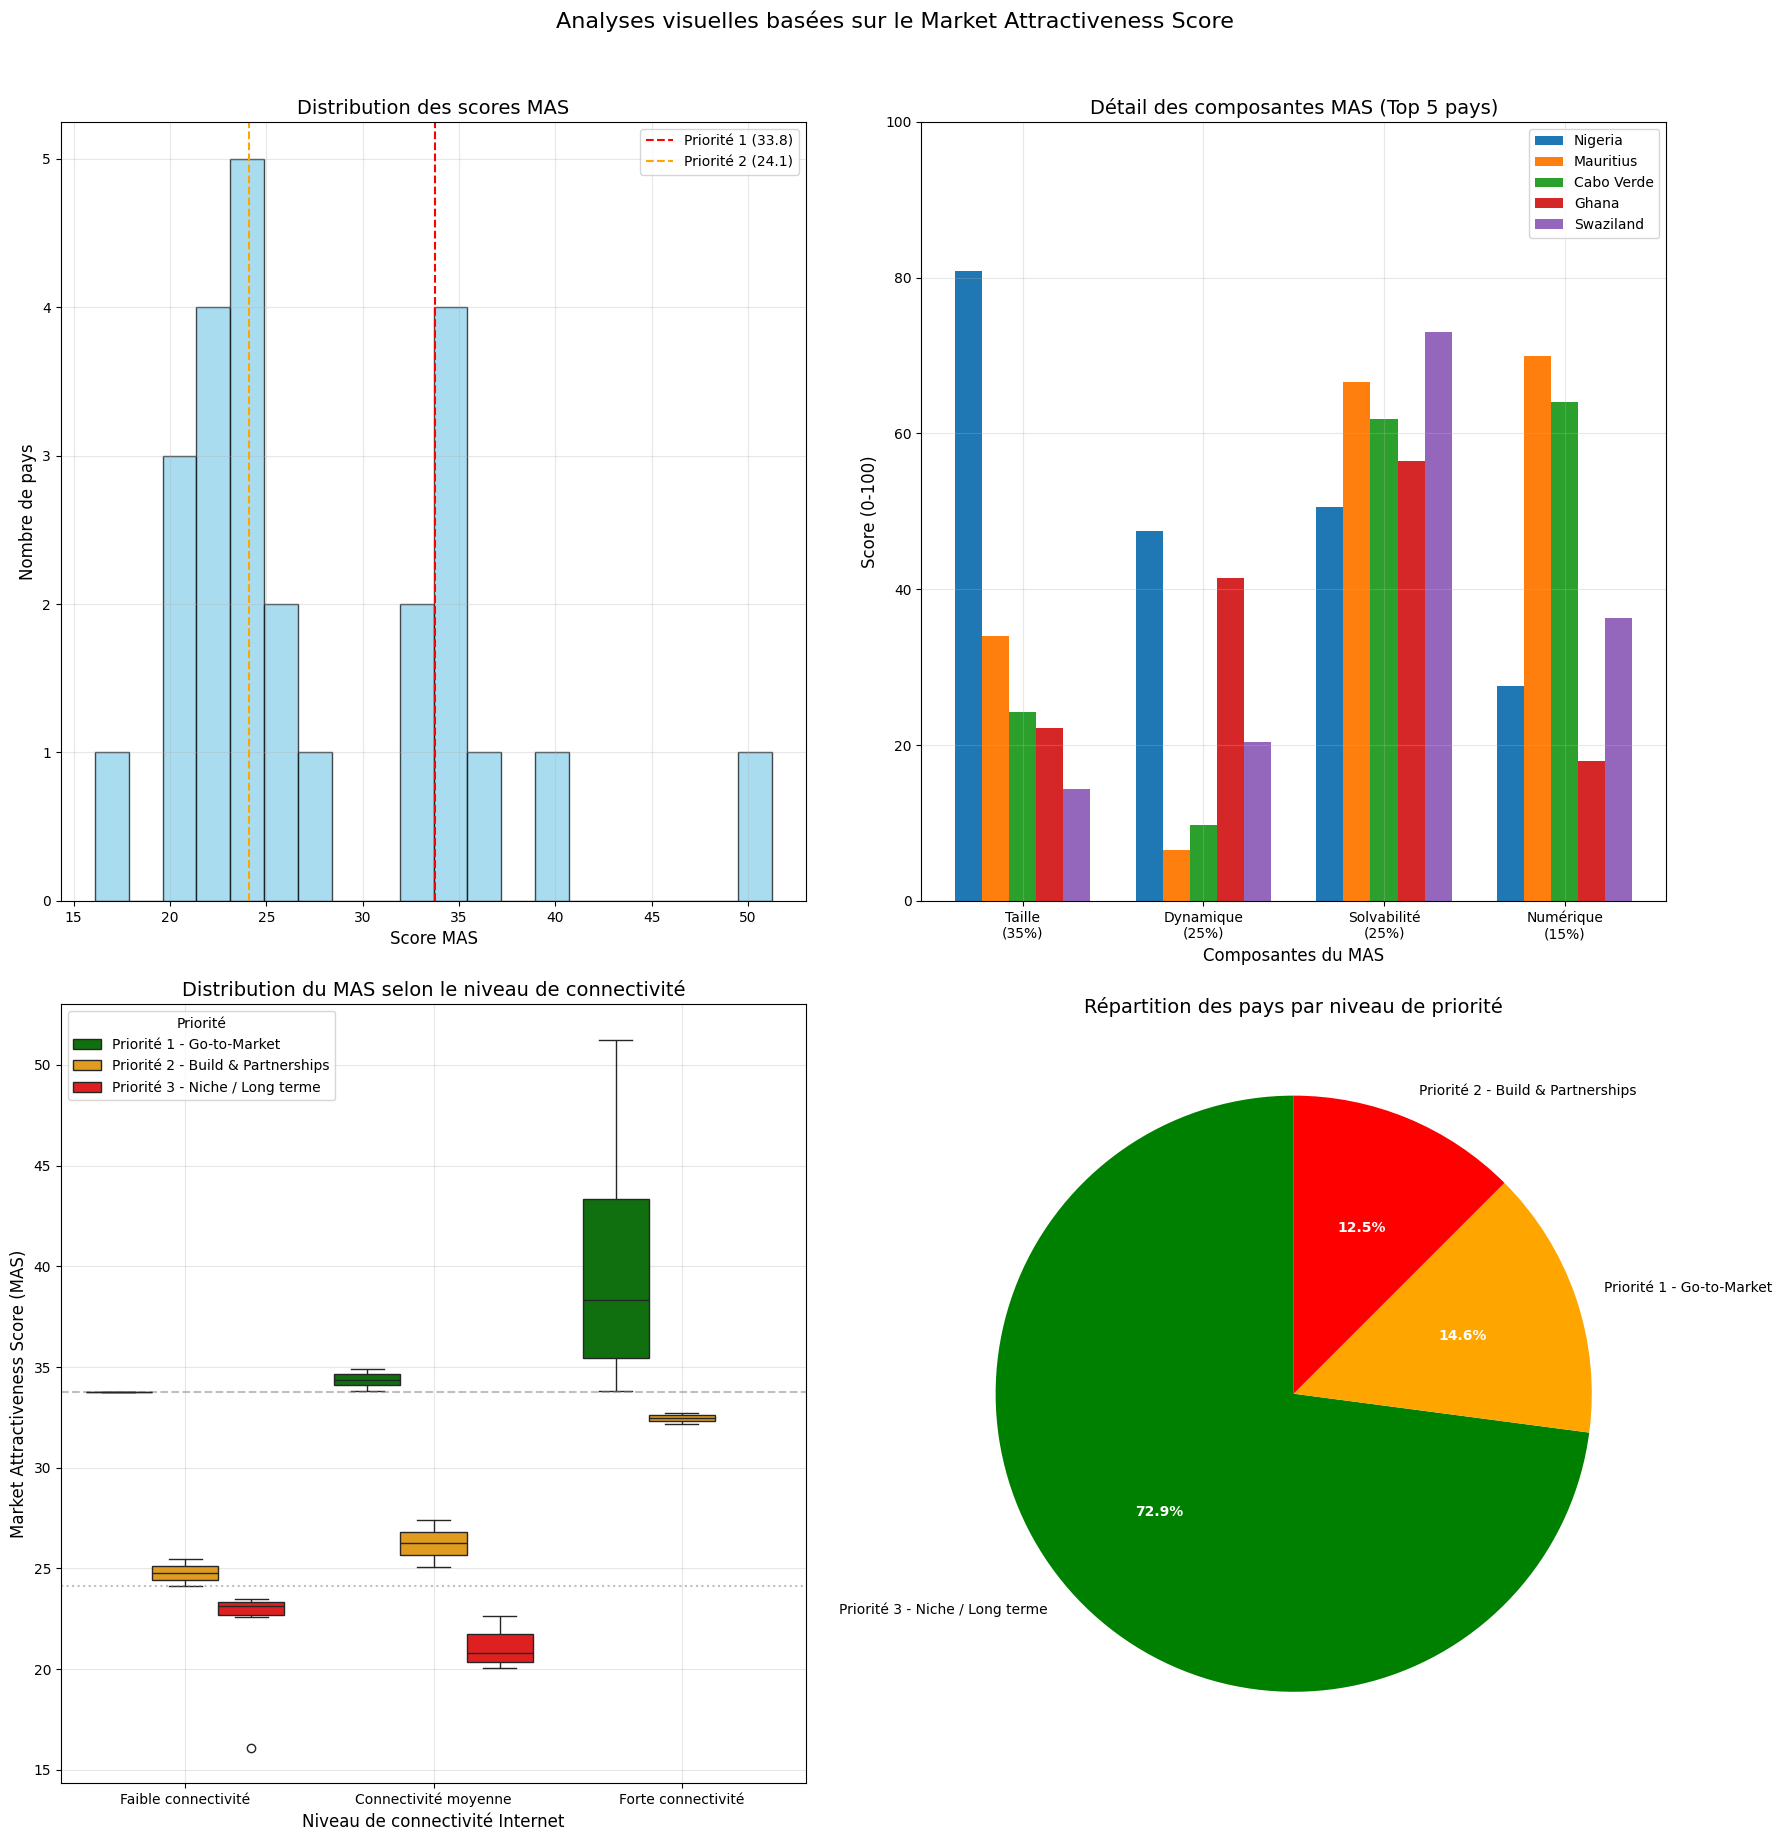

In [147]:
# Visualisation 2: Détail des composantes MAS pour le top 10
fig, axes = plt.subplots(2, 2, figsize=(18, 18))
top_10 = mas_df.head(10)

# 1. Distribution des scores MAS
ax1 = axes[0, 0]
ax1.hist(mas_df['MAS_Adjusted'], bins=20, color='skyblue', edgecolor='black', alpha=0.7)
ax1.axvline(x=threshold_high, color='red', linestyle='--', label=f'Priorité 1 ({threshold_high:.1f})')
ax1.axvline(x=threshold_medium, color='orange', linestyle='--', label=f'Priorité 2 ({threshold_medium:.1f})')
ax1.set_xlabel('Score MAS', fontsize=12)
ax1.set_ylabel('Nombre de pays', fontsize=12)
ax1.set_title('Distribution des scores MAS', fontsize=14)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Comparaison des composantes pour le top 5
ax2 = axes[0, 1]
top_5_countries = top_10.head(5)['Country'].tolist()
categories = ['Scale_Score', 'Momentum_Score', 'Ability_Score', 'Readiness_Score']
x = np.arange(len(categories))
width = 0.15

for i, country in enumerate(top_5_countries):
    country_data = mas_df[mas_df['Country'] == country].iloc[0]
    scores = [country_data[cat] for cat in categories]
    ax2.bar(x + i*width - 2*width, scores, width, label=country)

ax2.set_xlabel('Composantes du MAS', fontsize=12)
ax2.set_ylabel('Score (0-100)', fontsize=12)
ax2.set_title('Détail des composantes MAS (Top 5 pays)', fontsize=14)
ax2.set_xticks(x)
ax2.set_xticklabels(['Taille\n(35%)', 'Dynamique\n(25%)', 'Solvabilité\n(25%)', 'Numérique\n(15%)'], fontsize=10)
ax2.legend(fontsize=10)
ax2.set_ylim([0, 100])
ax2.grid(True, alpha=0.3)

# 3. Distribution du MAS selon le niveau de connectivité

mas_df["Connectivite_cat"] = pd.qcut(
    mas_df["Internet_Users"],
    q=3,
    labels=["Faible connectivité", "Connectivité moyenne", "Forte connectivité"]
)
ax3 = axes[1, 0]

sns.boxplot(
    data=mas_df,
    x="Connectivite_cat",
    y="MAS_Adjusted",
    hue="Priority",
    palette=priority_colors,
    ax=ax3
)

ax3.set_xlabel("Niveau de connectivité Internet", fontsize=12)
ax3.set_ylabel("Market Attractiveness Score (MAS)", fontsize=12)
ax3.set_title("Distribution du MAS selon le niveau de connectivité", fontsize=14)

# Lignes de seuil MAS
ax3.axhline(y=threshold_high, color='gray', linestyle='--', alpha=0.5)
ax3.axhline(y=threshold_medium, color='gray', linestyle=':', alpha=0.5)

ax3.legend(title="Priorité", fontsize=10)
ax3.grid(True, alpha=0.3)

# 4. Répartition par priorité
ax4 = axes[1, 1]
priority_counts = mas_df['Priority'].value_counts()
colors_priority = ['green', 'orange', 'red']
wedges, texts, autotexts = ax4.pie(priority_counts.values, labels=priority_counts.index,
                                   autopct='%1.1f%%', colors=colors_priority,
                                   startangle=90, textprops={'fontsize': 10})

# Améliorer l'affichage des pourcentages
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')

ax4.set_title('Répartition des pays par niveau de priorité', fontsize=14)

plt.suptitle('Analyses visuelles basées sur le Market Attractiveness Score', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('mas_analysis_visualizations.png', dpi=300, bbox_inches='tight')
plt.show()

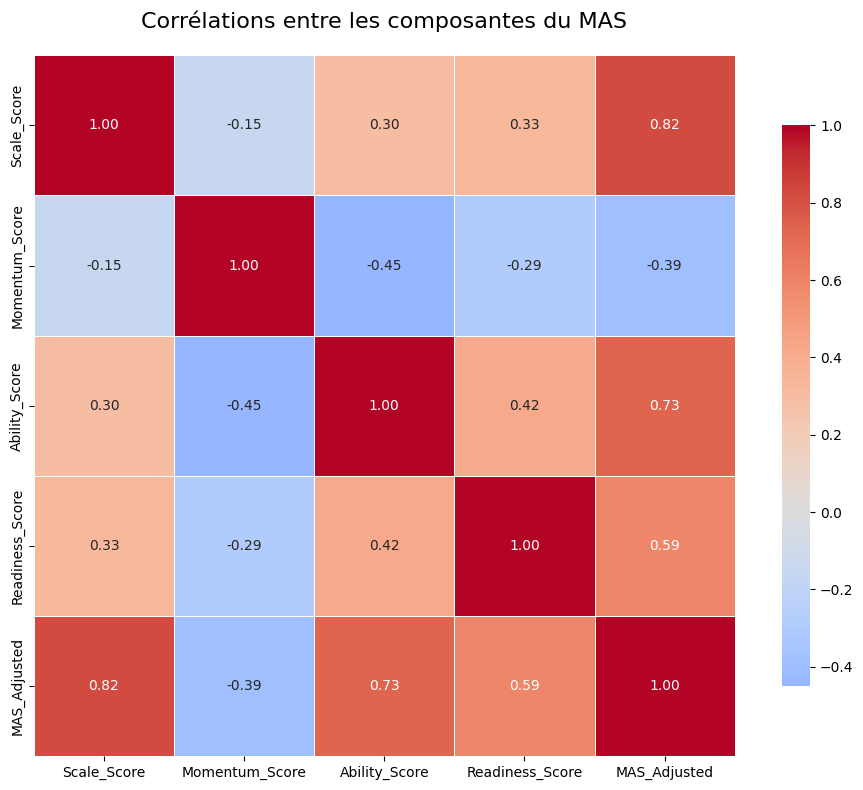

In [115]:
# Visualisation 3: Carte de chaleur des corrélations entre composantes
corr_matrix = mas_df[['Scale_Score', 'Momentum_Score', 'Ability_Score', 
                      'Readiness_Score', 'MAS_Adjusted']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Corrélations entre les composantes du MAS', fontsize=16, pad=20)
plt.tight_layout()
plt.savefig('mas_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Le Scale_Score est fortement corrélé au MAS_Adjusted (0,82) et modérément lié à l’Ability_Score (0,30) et au Readiness_Score (0,33), soulignant le rôle central de la taille du marché. Le Momentum_Score présente des corrélations négatives avec les autres composantes, notamment avec l’Ability_Score (-0,45) et le MAS_Adjusted (-0,39), indiquant que la dynamique éducative seule ne garantit pas une forte attractivité. Le MAS_Adjusted est principalement porté par la capacité économique (0,73) et la maturité numérique (0,59), confirmant que les fondamentaux structurels priment sur la croissance démographique isolée.

### L’attractivité des marchés EdTech est principalement tirée par la taille du marché, la solvabilité et la maturité numérique, tandis que la dynamique éducative seule n’est pas un facteur déterminant de succès à court terme.

## ÉVOLUTION TEMPORELLE DU MAS

### Évolution du MAS (2005–2015) : Le potentiel de marché EdTech en Afrique est structurellement en croissance.Les pays leaders consolident leur avance, renforçant leur attractivité à moyen terme.Les pays émergents montrent une dynamique positive, justifiant une veille stratégique continue.

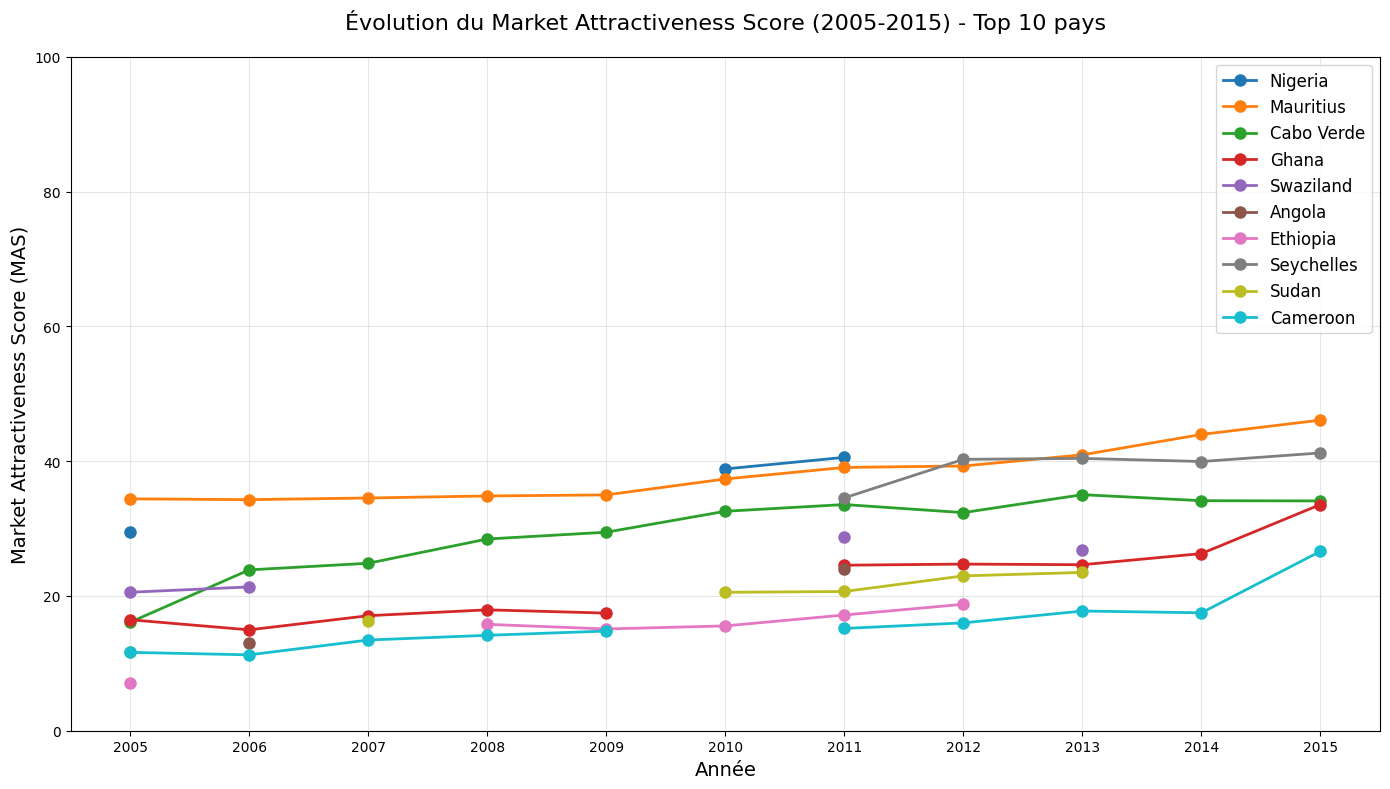

In [118]:
# Calculer l'évolution du MAS sur la période 2005-2015
mas_evolution = []

for year in range(2005, 2016):
    # Calculer le MAS pour chaque année
    year_mas_df = calculate_mas_score(wide_df[wide_df['Year'] == year], base_year=year)
    year_mas_df['Year'] = year
    mas_evolution.append(year_mas_df)

mas_evolution_df = pd.concat(mas_evolution, ignore_index=True)

# Analyser l'évolution du top 5
top_10_countries = mas_df.head(10)['Country'].tolist()

plt.figure(figsize=(14, 8))
for country in top_10_countries:
    country_data = mas_evolution_df[mas_evolution_df['Country'] == country]
    if not country_data.empty:
        plt.plot(country_data['Year'], country_data['MAS_Adjusted'], 
                marker='o', linewidth=2, markersize=8, label=country)

plt.xlabel('Année', fontsize=14)
plt.ylabel('Market Attractiveness Score (MAS)', fontsize=14)
plt.title('Évolution du Market Attractiveness Score (2005-2015) - Top 10 pays', fontsize=16, pad=20)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(range(2005, 2016))
plt.ylim([0, 100])

plt.tight_layout()
plt.savefig('mas_evolution_timeline.png', dpi=300, bbox_inches='tight')
plt.show()

## Le MAS met en évidence une Afrique à fort potentiel EdTech, mais nécessitant une stratégie sélective : un déploiement immédiat sur quelques marchés mûrs, combiné à une construction progressive sur la majorité des pays.

## ANALYSE DÉTAILLÉE DES PAYS PRIORITAIRES

In [133]:
# Analyse détaillée des pays Priorité 1
print("\n" + "*" * 60)
print("ANALYSE DÉTAILLÉE - PAYS PRIORITÉ 1 (Go-to-Market)")
print("*" * 60)

for _, country_row in priority_1.sort_values('MAS_Adjusted', ascending=False).iterrows():
    print(f"\n📊 {country_row['Country']} - MAS: {country_row['MAS_Adjusted']:.1f}/100")
    print("-" * 40)
    
    # Forces et faiblesses
    print("Forces principales:")
    scores = {
        'Taille du marché': country_row['Scale_Score'],
        'Dynamique de croissance': country_row['Momentum_Score'],
        'Capacité de paiement': country_row['Ability_Score'],
        'Faisabilité numérique': country_row['Readiness_Score']
    }
    
    # Trier par score décroissant
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    for i, (indicator, score) in enumerate(sorted_scores[:2], 1):
        print(f"  {i}. {indicator}: {score:.1f}/100")
    
    # Recommandations spécifiques
    print("\nRecommandations pour Akowé:")
    
    if country_row['Readiness_Score'] >= 70:
        print("  • Lancement direct B2C possible (bonne connectivité)")
    else:
        print("  • Approche B2B/B2G recommandée (connectivité modérée)")
    
    if country_row['Ability_Score'] >= 60:
        print("  • Modèle freemium ou premium viable")
    else:
        print("  • Modèle à bas prix ou subventionné")
    
    if country_row['Scale_Score'] >= 80:
        print("  • Cibler mass market avec contenus généralistes")
    else:
        print("  • Approche niche avec spécialisations")

print("*" * 60)


************************************************************
ANALYSE DÉTAILLÉE - PAYS PRIORITÉ 1 (Go-to-Market)
************************************************************

📊 Nigeria - MAS: 51.3/100
----------------------------------------
Forces principales:
  1. Taille du marché: 80.8/100
  2. Capacité de paiement: 50.6/100

Recommandations pour Akowé:
  • Approche B2B/B2G recommandée (connectivité modérée)
  • Modèle à bas prix ou subventionné
  • Cibler mass market avec contenus généralistes

📊 Mauritius - MAS: 40.7/100
----------------------------------------
Forces principales:
  1. Faisabilité numérique: 69.9/100
  2. Capacité de paiement: 66.6/100

Recommandations pour Akowé:
  • Approche B2B/B2G recommandée (connectivité modérée)
  • Modèle freemium ou premium viable
  • Approche niche avec spécialisations

📊 Cabo Verde - MAS: 36.0/100
----------------------------------------
Forces principales:
  1. Faisabilité numérique: 64.0/100
  2. Capacité de paiement: 61.9/100

Recomm

In [128]:
# Identifier les pays avec la plus forte progression
mas_growth = []
for country in mas_evolution_df['Country'].unique():
    country_data = mas_evolution_df[mas_evolution_df['Country'] == country].sort_values('Year')
    if len(country_data) >= 2:
        start_mas = country_data.iloc[0]['MAS_Adjusted']
        end_mas = country_data.iloc[-1]['MAS_Adjusted']
        growth = end_mas - start_mas
        mas_growth.append({
            'Country': country,
            'MAS_Growth': growth,
            'Start_MAS': start_mas,
            'End_MAS': end_mas
        })

growth_df = pd.DataFrame(mas_growth).sort_values('MAS_Growth', ascending=False)

print("\n" + "*" * 60)
print("PAYS AVEC LA PLUS FORTE CROISSANCE DU MAS (2005-2015)")
print("*" * 60)
print("\nTop 10 des pays par croissance du MAS:\n")

for i, (_, row) in enumerate(growth_df.head(10).iterrows(), 1):
    print(f"{i:2d}. {row['Country']:25s} "
          f"Growth: {row['MAS_Growth']:+.1f} "
          f"({row['Start_MAS']:.1f} → {row['End_MAS']:.1f})")

print("*" * 60)


************************************************************
PAYS AVEC LA PLUS FORTE CROISSANCE DU MAS (2005-2015)
************************************************************

Top 10 des pays par croissance du MAS:

 1. Cabo Verde                Growth: +18.0 (16.1 → 34.1)
 2. Ghana                     Growth: +17.1 (16.5 → 33.6)
 3. Rwanda                    Growth: +15.3 (3.2 → 18.5)
 4. Cameroon                  Growth: +15.0 (11.6 → 26.6)
 5. Mauritius                 Growth: +11.7 (34.4 → 46.1)
 6. Mozambique                Growth: +8.8 (8.7 → 17.5)
 7. Mauritania                Growth: +5.5 (5.4 → 10.9)
 8. Senegal                   Growth: +5.5 (13.8 → 19.3)
 9. Angola                    Growth: +nan (nan → nan)
10. Benin                     Growth: +nan (10.1 → nan)
************************************************************
